# Titanic Survival Analysis

## Project Overview

The Titanic disaster is one of the most famous shipwrecks in history.

The goal of this analysis is to explore the factors that influenced passenger survival and identify patterns in the dataset before building machine learning models.

### Questions to Investigate
- Did gender affect survival?
- Did passenger class affect survival?
- Did age affect survival?
- Did ticket fare affect survival?
- Did family size affect survival?
- What characteristics were common among survivors?

## Import Libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler,PolynomialFeatures,PowerTransformer
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
from sklearn.feature_selection import SelectKBest , f_classif

%matplotlib inline
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore" , category=FutureWarning)

## Read Data

In [2]:
df = sns.load_dataset('titanic')

## Data Preparation

### 1. Data Understanding

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df_filtered = df.copy().drop(["alive", "class", "embarked", "alone", "adult_male"], axis=1)

In [5]:
df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,deck,embark_town
0,0,3,male,22.0,1,0,7.2500,man,NaN,Southampton
1,1,1,female,38.0,1,0,71.2833,woman,C,Cherbourg
2,1,3,female,26.0,0,0,7.9250,woman,NaN,Southampton
3,1,1,female,35.0,1,0,53.1000,woman,C,Southampton
4,0,3,male,35.0,0,0,8.0500,man,NaN,Southampton


In [6]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   who          891 non-null    object  
 8   deck         203 non-null    category
 9   embark_town  889 non-null    object  
dtypes: category(1), float64(2), int64(4), object(3)
memory usage: 64.0+ KB


In [7]:
df_filtered.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df_filtered.describe(include= "object")

,sex,who,embark_town
count,891,891,889
unique,2,3,3
top,male,man,Southampton
freq,577,537,644


#### Column meanings

- `survived`: target variable (0 = did not survive, 1 = survived)
- `pclass`: passenger class
- `age`: passenger age
- `sibsp`: number of siblings aboard
- `parch`: number of parents/children aboard
- `fare`: ticket fare
- `embark_town`: port of embarkation
- `who`: child, woman, or man

The columns `alive`, `class`, `embarked`, `alone`, and `adult_male` are redundant for this analysis.

### 2. Check for Dtypes

In [9]:
dtypes = df_filtered.dtypes
num_unique = df_filtered.nunique() 

pd.DataFrame({
    'Dtypes' : dtypes,
    'Num_Unique' : num_unique
}).T

,survived,pclass,sex,age,sibsp,parch,fare,who,deck,embark_town
Dtypes,int64,int64,object,float64,int64,int64,float64,object,category,object
Num_Unique,2,3,2,88,7,7,248,3,7,3


In [10]:
df_filtered[['survived','pclass','who','embark_town','sibsp','parch']] = df_filtered[['survived','pclass','who','embark_town','sibsp','parch']].astype('category')

In [11]:
dtypes = df_filtered.dtypes
num_unique = df_filtered.nunique() 

pd.DataFrame({
    'Dtypes' : dtypes,
    'Num_Unique' : num_unique
}).T

,survived,pclass,sex,age,sibsp,parch,fare,who,deck,embark_town
Dtypes,category,category,object,float64,category,category,float64,category,category,category
Num_Unique,2,3,2,88,7,7,248,3,7,3


### 3. Null Values

In [12]:
df_filtered.isnull().sum().sort_values(ascending = False)

deck           688
age            177
embark_town      2
survived         0
pclass           0
sex              0
parch            0
sibsp            0
who              0
fare             0
dtype: int64

In [13]:
missing_percentage  = df_filtered.isna().mean() * 100 
missing_percentage[missing_percentage > 0].round(2).sort_values(ascending = False)

deck           77.22
age            19.87
embark_town     0.22
dtype: float64

#### Missing-value treatment

- `age`: fill missing values with the median because age is numerical and the median is less affected by outliers.
- `embark_town`: remove the few rows with missing embarkation information.
- `deck`: remove the column because it contains a large amount of missing data and is not needed for this analysis.

In [14]:
df_filtered["age"] = df_filtered["age"].fillna(df_filtered["age"].median()) 

rows_to_del = df_filtered[df_filtered.embark_town.isna()].index 
df_filtered.drop(rows_to_del , inplace= True)

df_filtered.drop('deck' ,axis=1,inplace=True)

In [15]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    category
 1   pclass       889 non-null    category
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    category
 5   parch        889 non-null    category
 6   fare         889 non-null    float64 
 7   who          889 non-null    category
 8   embark_town  889 non-null    category
dtypes: category(6), float64(2), object(1)
memory usage: 34.2+ KB


In [16]:
missing_percentage  = df_filtered.isna().mean() * 100 
missing_percentage.round(2).sort_values(ascending = False)

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
who            0.0
embark_town    0.0
dtype: float64

In [17]:
numerical_cols = df_filtered.select_dtypes('number').columns
numerical_cols

Index(['age', 'fare'], dtype='object')

### 4. Outliers

<Axes: xlabel='age'>

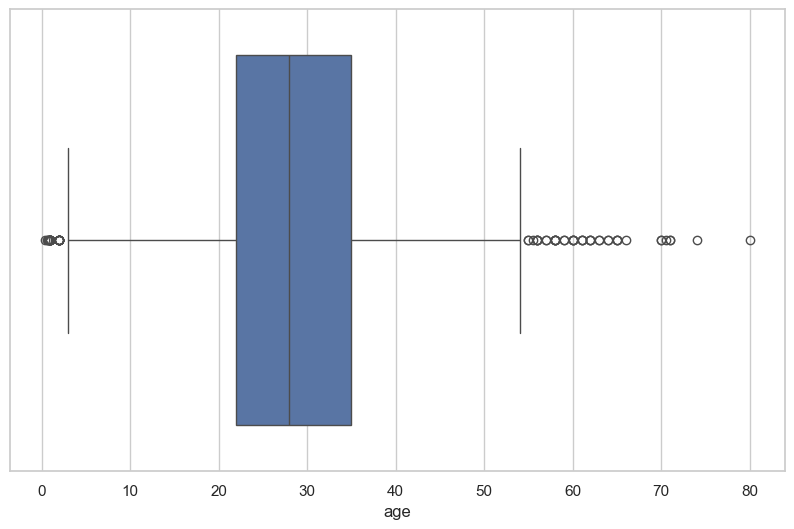

In [18]:
plt.figure(figsize= (10,6))
sns.boxplot(data = df_filtered , x='age')

In [19]:
Q1 = df_filtered.age.quantile(0.25)
Q3 = df_filtered.age.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

upper_outliers = df_filtered[df_filtered.age > upper]['age'].values 
df_filtered.age.replace(upper_outliers , upper ,inplace= True)

lower_outliers = df_filtered[df_filtered.age < lower]['age'].values 
df_filtered.age.replace(lower_outliers , lower ,inplace= True)

In [20]:
print("--- Age ---")
print(f'Lower: {lower} | Upper: {upper}')

--- Age ---
Lower: 2.5 | Upper: 54.5


<Axes: xlabel='age'>

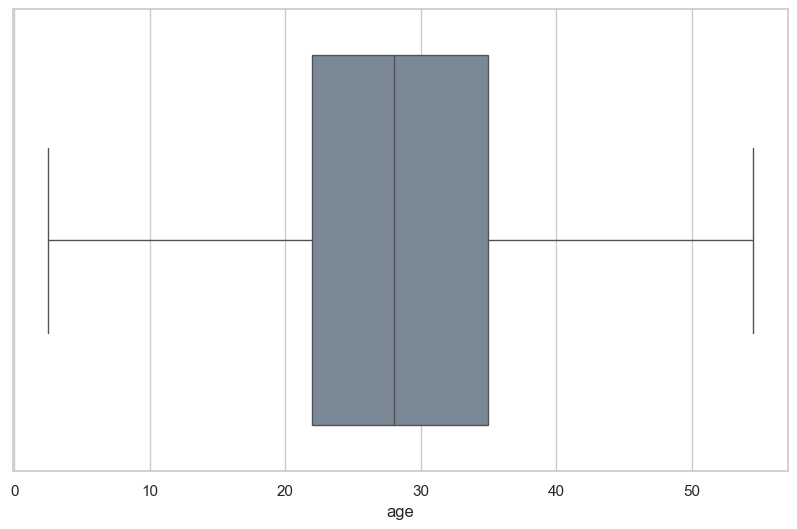

In [21]:
plt.figure(figsize= (10,6))
sns.boxplot(data = df_filtered , x='age',color='lightslategray')

<Axes: xlabel='fare'>

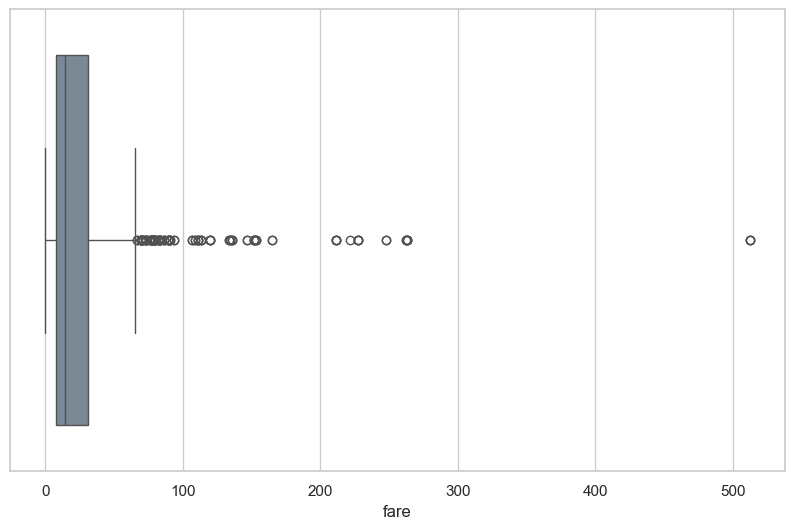

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df_filtered , x = 'fare',color='lightslategray')

In [23]:
Q1 = df.fare.quantile(.25)
Q3 = df.fare.quantile(.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

upper_outliers = df_filtered[df_filtered.fare > upper]["fare"].values
df_filtered.fare.replace(upper_outliers, upper, inplace = True)

In [24]:
print("--- Fare ---")
print(f'Lower: {lower} | Upper: {upper}')

--- Fare ---
Lower: 2.5 | Upper: 65.6344


<Axes: xlabel='fare'>

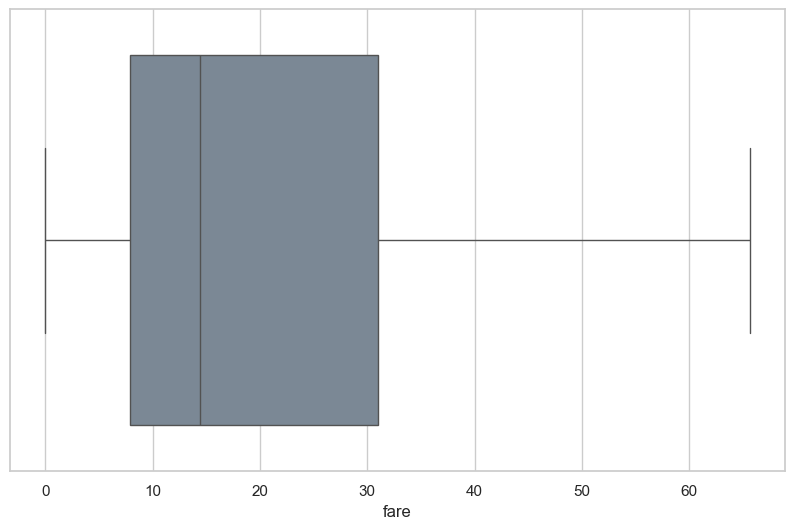

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df_filtered , x = 'fare',color='lightslategray')

## Feature Engineering

### 1. Encoding Categorical Data
Definition: Converting categories into numeric format.

#### a. Label Encoding
Label Encoding for binary categories  (Ordinal data)

In [26]:
label_encoder = LabelEncoder() 

df_filtered['pclass'] = label_encoder.fit_transform(df_filtered['pclass'])

df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town
0,0,2,male,22.0,1,0,7.2500,man,Southampton
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg
2,1,2,female,26.0,0,0,7.9250,woman,Southampton
3,1,0,female,35.0,1,0,53.1000,woman,Southampton
4,0,2,male,35.0,0,0,8.0500,man,Southampton


#### b. OneHot Encoding
One-Hot Encoding for multi-class  (Nominal data)

In [27]:
# df_filtered = pd.get_dummies(
#     df_filtered,
#     columns=['sex', 'embark_town'],
#     dtype=int
# )

onehot_encoder = OneHotEncoder(sparse_output=False)

encoded = onehot_encoder.fit_transform(
    df_filtered[['sex', 'embark_town']]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=onehot_encoder.get_feature_names_out(['sex', 'embark_town']),
    index=df_filtered.index
)

df_filtered = pd.concat([df_filtered, encoded_df], axis=1)

df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0


### 2. Feature Scaling
Definition: Normalizing the range of features.

#### a. Standardization (Z-score)

Center around 0
(... -2  -1   0   1   2 ...)

In [28]:
scalar = StandardScaler()
df_filtered['fare_scaled'] = scalar.fit_transform(df_filtered[['fare']])
df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,fare_scaled
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.818876
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0,2.043417
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0,-0.785784
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0,1.428918
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.779656


#### b. Min-Max Scaling:

Put everything between 0 and 1

( 0 ───── 0.5 ───── 1 )

In [29]:
min_max_scaler = MinMaxScaler() 
df_filtered['age_scaled'] = min_max_scaler.fit_transform(df_filtered[['age']])
df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,fare_scaled,age_scaled
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.818876,0.375000
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0,2.043417,0.682692
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0,-0.785784,0.451923
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0,1.428918,0.625000
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.779656,0.625000


### 3. Feature Transformation
Definition: Applying functions to features to improve their distribution.

In [30]:
def visualize_transformation(df, column, transform_func, title="Feature Transformation"):
    """
    Visualize feature before and after transformation
    
    Args:
        df (DataFrame): Input dataset
        column (str): Column to transform
        transform_func (callable): Transformation function that takes array and returns transformed array
        title (str): Title of the visualization
    """
    
    original = df[column].dropna()
    transformed = transform_func(original.values.reshape(-1, 1)).flatten()
    
    # Skewness calculation
    skew_before = pd.Series(original).skew()
    skew_after = pd.Series(transformed).skew()
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=16)
    
    # Histogram before
    sns.histplot(original, kde=True, ax=axes[0,0], color="skyblue")
    axes[0,0].set_title(f"Original {column}\nSkewness = {skew_before:.2f}")
    
    # Histogram after
    sns.histplot(transformed, kde=True, ax=axes[0,1], color="lightgreen")
    axes[0,1].set_title(f"Transformed {column}\nSkewness = {skew_after:.2f}")
    
    # Boxplot before
    sns.boxplot(x=original, ax=axes[1,0], color="skyblue")
    axes[1,0].set_title("Original Boxplot")
    
    # Boxplot after
    sns.boxplot(x=transformed, ax=axes[1,1], color="lightgreen")
    axes[1,1].set_title("Transformed Boxplot")
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


#### a. Log Transform
useful for right-skewed data

In [31]:
# Log transform skewed feature
df_filtered['fare_log'] = np.log1p(df['fare'])
df_filtered[['fare','fare_log']].head()

,fare,fare_log
0,7.2500,2.110213
1,65.6344,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


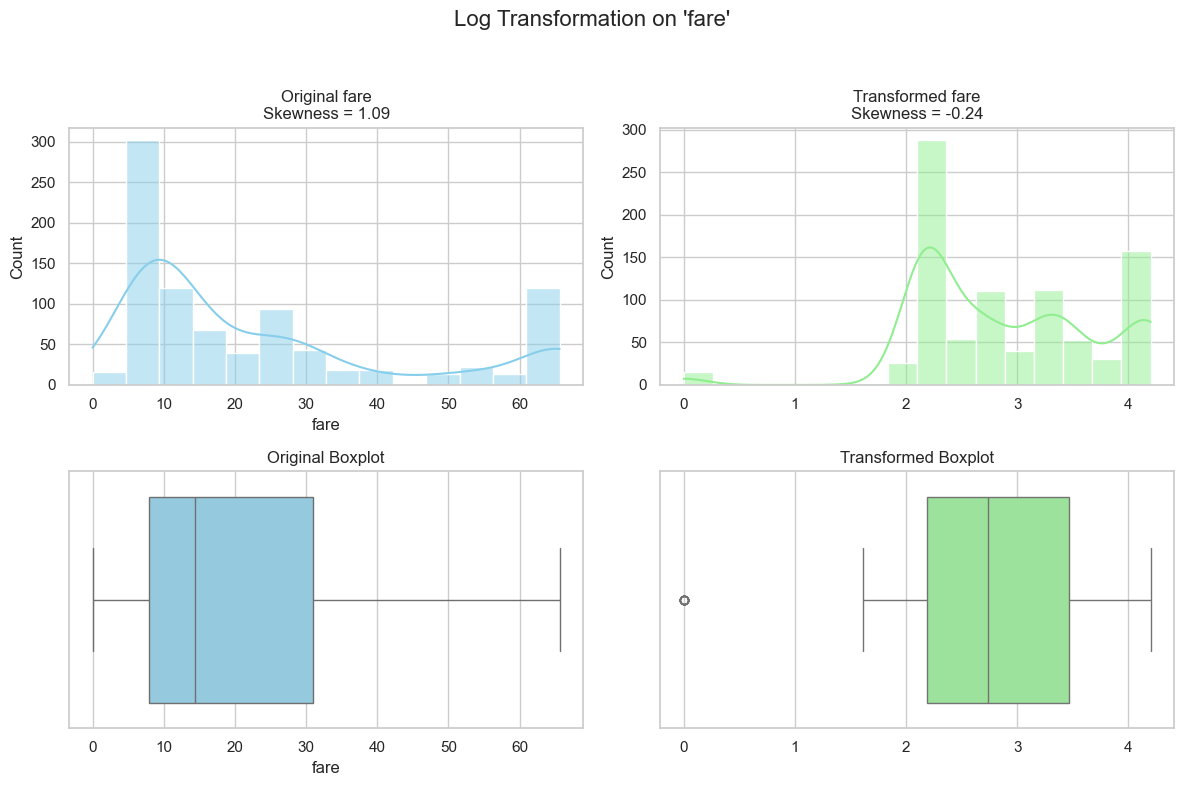

In [32]:
# Log transformation example
visualize_transformation(
    df_filtered,
    'fare',
    transform_func = lambda x : np.log1p(x),
    title="Log Transformation on 'fare'"
)

#### b. Box-Cox or Yeo-Johnson (for non-normal data)

In [33]:
pt = PowerTransformer() 
df_filtered['age_power'] = pt.fit_transform(df_filtered[['age']])
df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,fare_scaled,age_scaled,fare_log,age_power
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.818876,0.375000,2.110213,-0.560017
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0,2.043417,0.682692,4.280593,0.752492
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0,-0.785784,0.451923,2.188856,-0.224824
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0,1.428918,0.625000,3.990834,0.511554
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.779656,0.625000,2.202765,0.511554


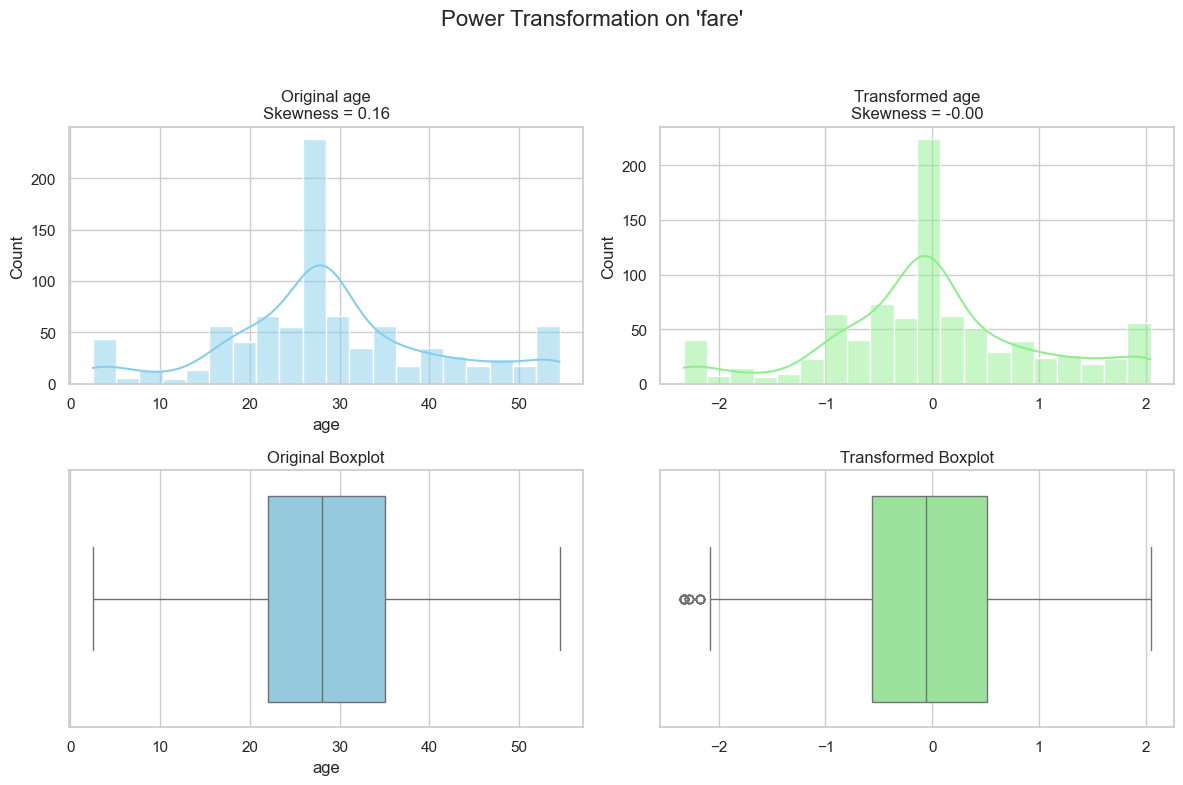

In [34]:
visualize_transformation(
    df_filtered,
    'age', 
    transform_func= pt.fit_transform,
    title="Power Transformation on 'fare'"
)

### 4. Interaction Features
Definition: Creating features by combining two or more features.

In [35]:
# Family size feature
df_filtered["sibsp"] = pd.to_numeric(df_filtered["sibsp"])
df_filtered["parch"] = pd.to_numeric(df_filtered["parch"])
df_filtered["Family_size"] = df_filtered["sibsp"] + df_filtered["parch"] + 1

df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,fare_scaled,age_scaled,fare_log,age_power,Family_size
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.818876,0.375000,2.110213,-0.560017,2
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0,2.043417,0.682692,4.280593,0.752492,2
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0,-0.785784,0.451923,2.188856,-0.224824,1
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0,1.428918,0.625000,3.990834,0.511554,2
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.779656,0.625000,2.202765,0.511554,1


### 5. Binning / Discretization
Definition: Converting continuous values into bins or categories.

In [36]:
bins = [1,13,18,65,float("inf")]
labels = ["Child" ,"Teenager " , "Adult" , "Elderly"]

df_filtered["Age_category"] = pd.cut(df_filtered["age"],
                                       bins= bins,
                                       labels= labels)

df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,fare_scaled,age_scaled,fare_log,age_power,Family_size,Age_category
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.818876,0.375000,2.110213,-0.560017,2,Adult
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0,2.043417,0.682692,4.280593,0.752492,2,Adult
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0,-0.785784,0.451923,2.188856,-0.224824,1,Adult
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0,1.428918,0.625000,3.990834,0.511554,2,Adult
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.779656,0.625000,2.202765,0.511554,1,Adult


### 6. Polynomial Features
Definition: Generating interaction and power terms.

In [37]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_filtered[['age', 'fare']].fillna(0))
print(f"Polynomial features shape: {poly_features.shape}")

Polynomial features shape: (889, 5)


### 7. Feature Selection
Definition: Selecting important features.

## Visualization

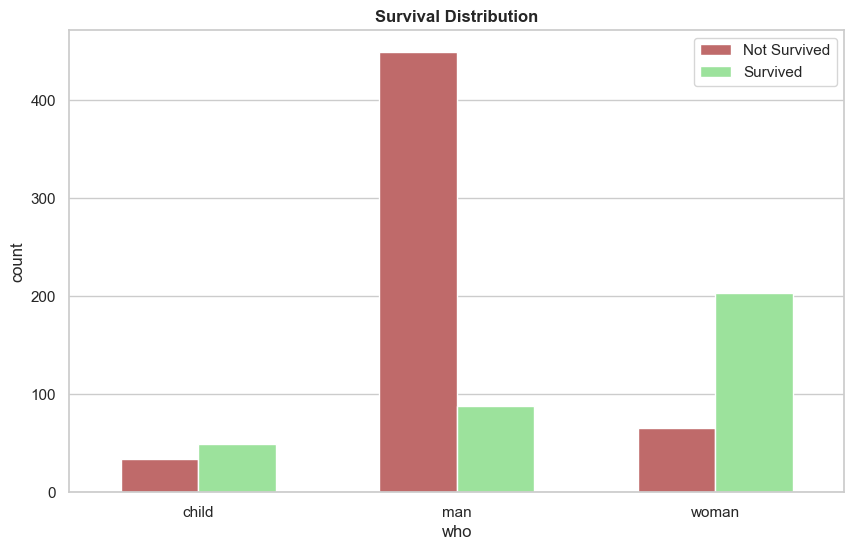

In [38]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_filtered , x="who" , hue= 'survived',
              palette= ["indianred","lightgreen"] , width=0.6)
plt.title("Survival Distribution",fontweight = "bold")
plt.legend(['Not Survived' ,'Survived'])
plt.show()

In [39]:
sex_survival = pd.crosstab(df_filtered['who'], df_filtered['survived'], normalize='index') * 100
sex_survival.columns = ['Not Survived %', 'Survived %']
sex_survival.round(2)

,Not Survived %,Survived %
who,,
child,40.96,59.04
man,83.61,16.39
woman,24.54,75.46


#### Survival by Gender

#### Business Insight
- Female passengers had significantly higher survival rates than children and males passengers.
- Childerns passengers had significantly higher survival rates than male passengers.
- This supports the historical evacuation policy of "women and children first."
- Gender appears to be one of the strongest predictors of survival.

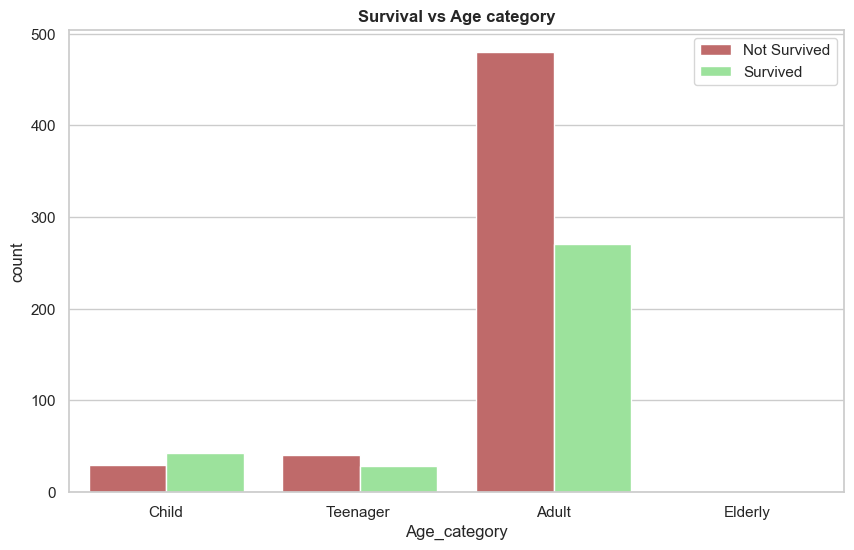

In [40]:
plt.figure(figsize=(10,6))
sns.countplot(data = df_filtered , x="Age_category" , 
              hue= "survived" , palette=["indianred","lightgreen"])
plt.title("Survival vs Age category",fontweight = "bold")
plt.legend(['Not Survived' ,'Survived'])
plt.show()

In [41]:
age_survival = pd.crosstab(df_filtered['Age_category'], df_filtered['survived'], normalize='index') * 100
age_survival.columns = ['Not Survived %', 'Survived %']
age_survival.round(2)

,Not Survived %,Survived %
Age_category,,
Child,40.85,59.15
Teenager,58.82,41.18
Adult,64.00,36.00


#### Survival by Age

#### Business Insight
- Most passengers were adults.
- A small number of elderly passengers are present.
- Younger passengers generally had higher survival rates.
- Children appear to have been prioritized during evacuation.
- Survival tends to decrease among older age groups.

Age appears to be a meaningful factor in survival outcomes.

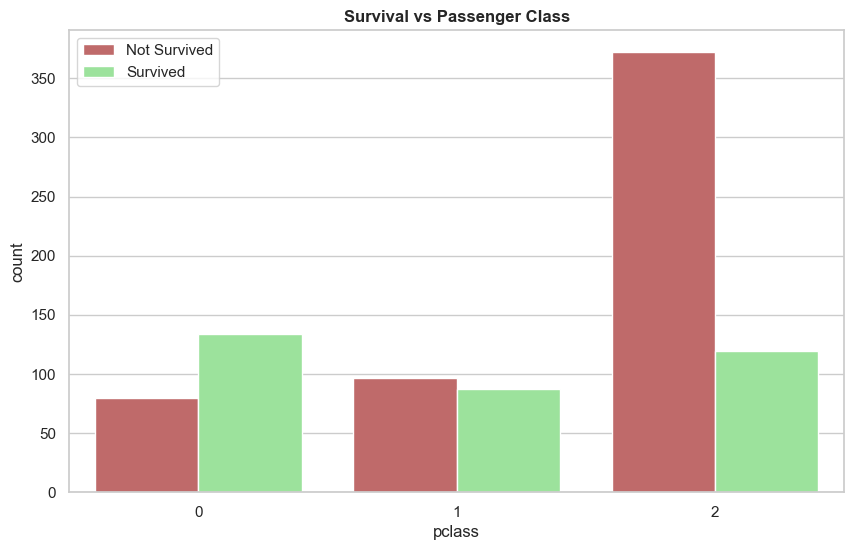

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(data = df_filtered , x="pclass" , 
              hue = "survived" , palette=["indianred","lightgreen"])
plt.title("Survival vs Passenger Class" , fontweight = "bold")
plt.legend(['Not Survived' ,'Survived'])
plt.savefig("Survival vs Passenger Class.jpg")
plt.show()

In [43]:
class_survival = pd.crosstab(df_filtered['pclass'], df_filtered['survived'], normalize='index') * 100
class_survival.columns = ['Not Survived %', 'Survived %']
class_survival.round(2)

,Not Survived %,Survived %
pclass,,
0,37.38,62.62
1,52.72,47.28
2,75.76,24.24


#### Survival by Passenger Class

#### Business Insight
- First-class passengers had the highest survival rates.
- Third-class passengers had the lowest survival rates.
- Passenger class appears to have played an important role during evacuation.

Possible explanation:
First-class passengers had better access to lifeboats and evacuation routes.

<Figure size 1000x600 with 0 Axes>

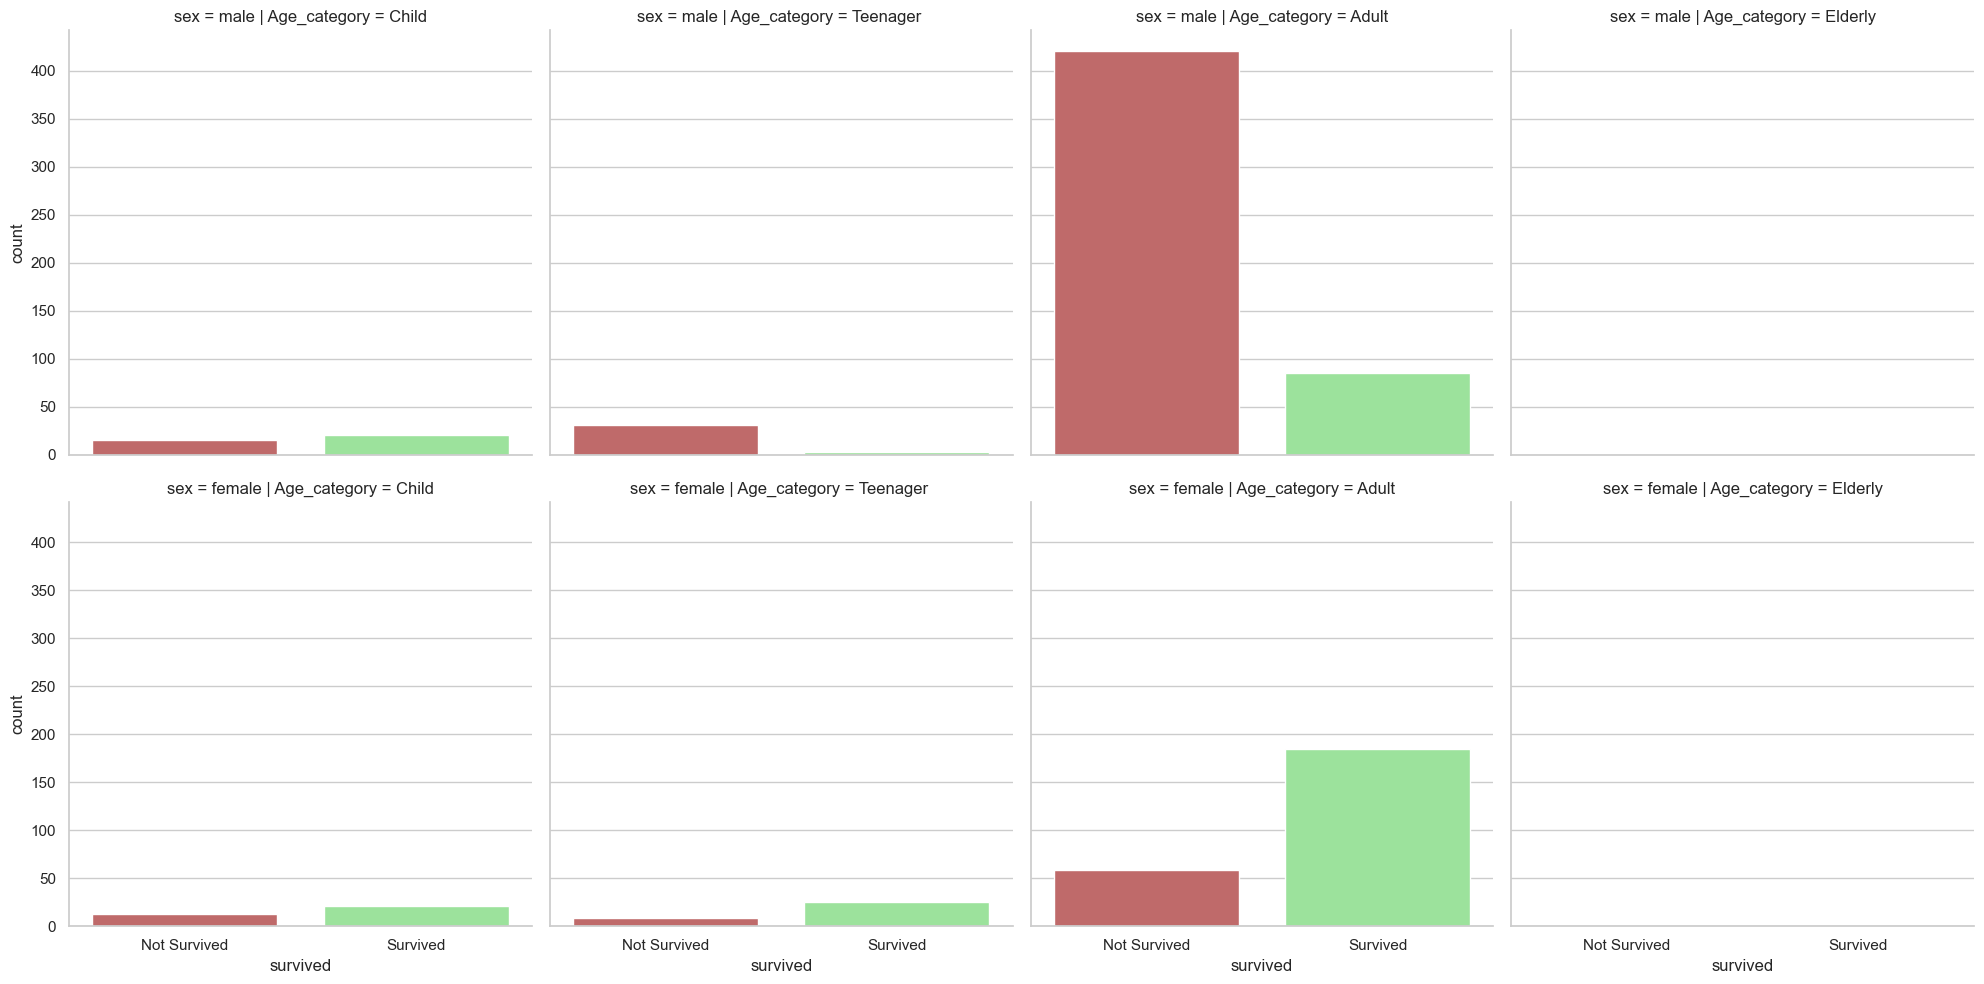

In [44]:
plt.figure(figsize=(10,6))
sns.catplot(data = df_filtered , x = "survived" , 
            kind = "count" , row = 'sex', col = "Age_category" , palette=["indianred","lightgreen"])
plt.xticks(ticks=[0,1] , labels= ["Not Survived" , "Survived"])
plt.savefig("Survived Vs Sex & Agecategory.jpg")
plt.show()

#### CatPlot Insights (Survived vs Sex & Age Category)

The catplot shows the relationship between survival, gender, and age category.

- Gender is the most important factor affecting survival. Females had a much higher       survival rate compared to males across all age categories.
- Children generally had better survival chances than adults, especially female children.
- Adult males show the lowest survival rate, with most of them not surviving.
- Age has an effect, but it is weaker compared to gender.
- Overall, survival was highly influenced by gender, with age acting as a secondary factor.

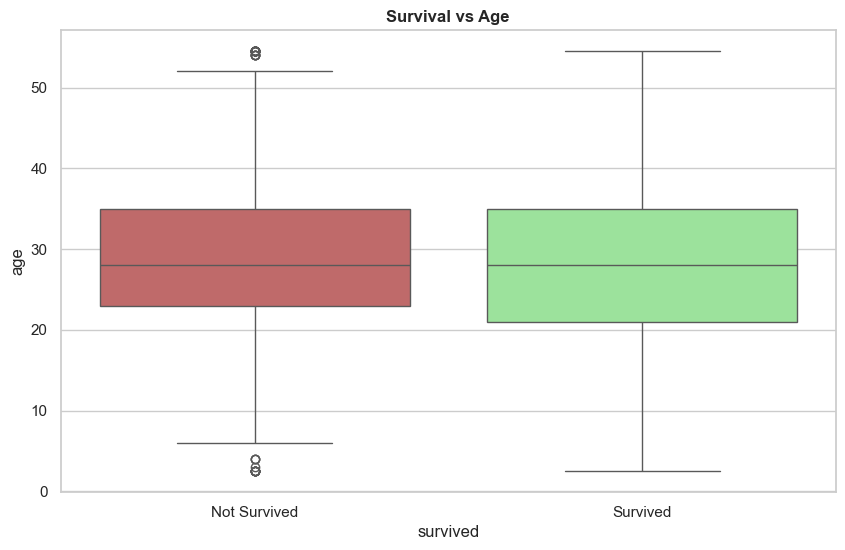

In [45]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df_filtered , x="survived" , y="age" ,  palette=["indianred","lightgreen"])
plt.xticks(ticks=[0,1] , labels= ["Not Survived" , "Survived"])
plt.title("Survival vs Age",fontweight = "bold")
plt.show()

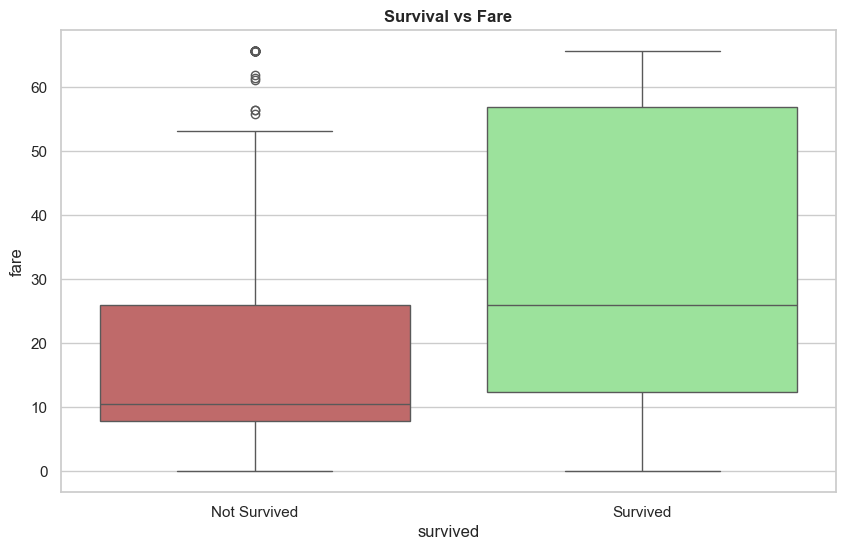

In [46]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_filtered , x="survived" , y="fare" ,palette=["indianred","lightgreen"])
plt.xticks(ticks=[0,1] , labels= ["Not Survived" , "Survived"])
plt.title("Survival vs Fare",fontweight = "bold")
plt.show()

#### Survival by Fare

#### Business Insight
- Passengers who paid higher fares generally had better survival rates.
- Higher fares are strongly associated with higher passenger classes.
- Wealthier passengers may have had better access to rescue opportunities.
- Most passengers paid relatively low fares.

<Figure size 1000x600 with 0 Axes>

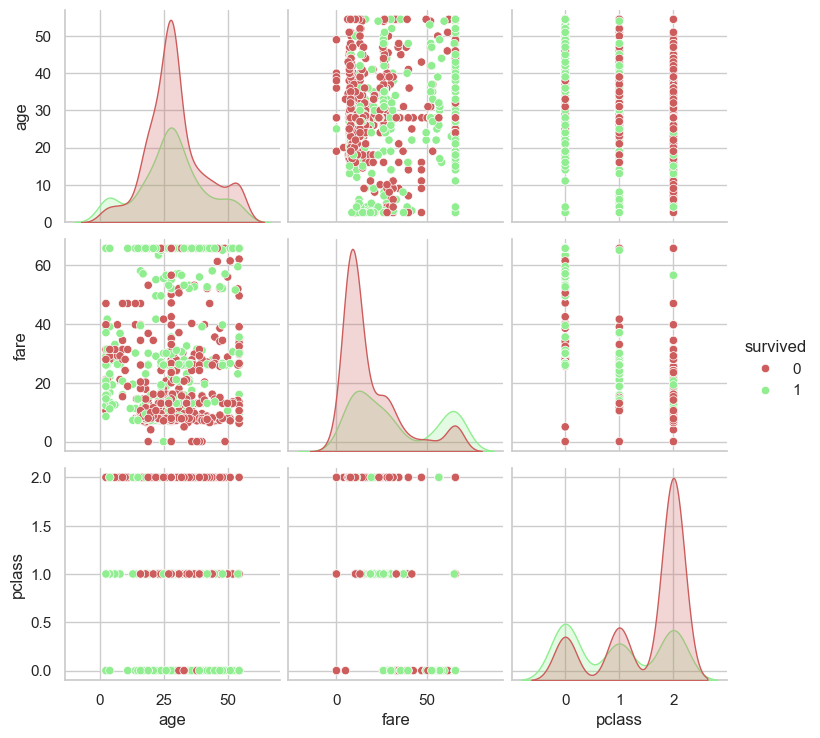

In [47]:
plt.figure(figsize=(10,6))
df_filtered["pclass"] = pd.to_numeric(df_filtered["pclass"])
sns.pairplot(df_filtered, hue="survived",vars= ["age","fare","pclass"]
            ,palette=["indianred","lightgreen"])
plt.savefig("pair plot.jpg")
plt.show()

#### PairPlot Insights (Age, Fare, Pclass vs Survived)

The pairplot explores the relationship between numerical features and survival.

- Passengers who paid higher fares had a higher chance of survival.
- First-class passengers (lower Pclass values) are more likely to survive, while third-   class passengers are mostly in the non-survived group.
- Age shows a weak relationship with survival, with no clear separation, although         children appear slightly more in the survived group.
- There is a strong relationship between Pclass and Fare, where higher classes            correspond to higher fares.
- Overall, survival is strongly associated with socio-economic status (Pclass and Fare), while age has a weaker effect.

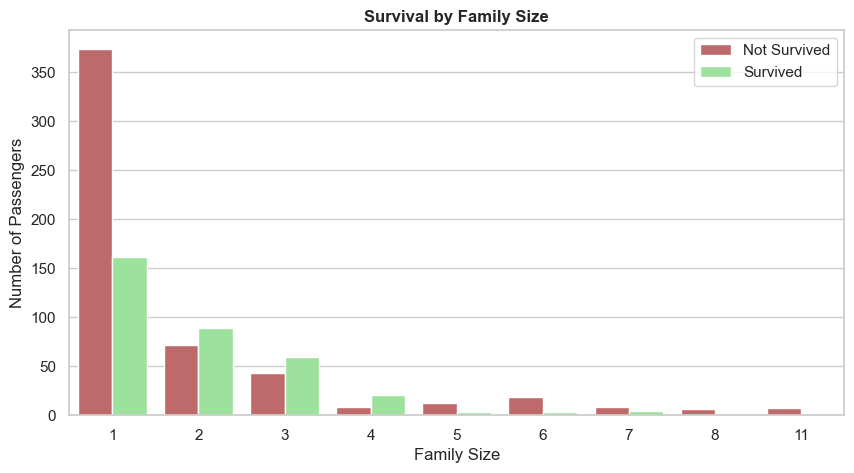

In [48]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df_filtered, x='Family_size', hue='survived', palette=['indianred', 'lightgreen'])

plt.title('Survival by Family Size', fontweight='bold')
plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')
plt.legend(['Not Survived', 'Survived'])
plt.show()

In [49]:
family_survival = pd.crosstab(df_filtered['Family_size'], df_filtered['survived'], normalize='index') * 100
family_survival.columns = ['Not Survived %', 'Survived %']
family_survival.round(2)

,Not Survived %,Survived %
Family_size,,
1,69.91,30.09
2,44.72,55.28
3,42.16,57.84
4,27.59,72.41
5,80.00,20.00
6,86.36,13.64
7,66.67,33.33
8,100.00,0.00
11,100.00,0.00


#### Survival by Family Size

#### Business Insight
- Passengers traveling with very large families had lower survival rates.
- Passengers traveling completely alone also experienced lower survival rates.
- Small and moderate-sized families appear to have had better survival chances.

This suggests that family size may influence evacuation outcomes.

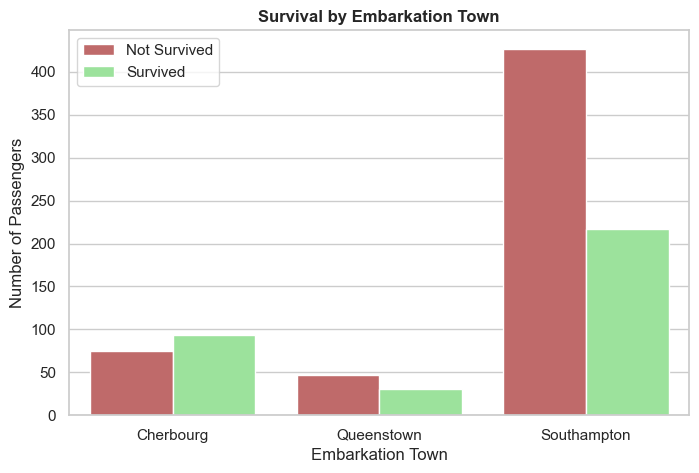

In [50]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_filtered, x='embark_town', hue='survived', palette=['indianred', 'lightgreen'])
plt.title('Survival by Embarkation Town', fontweight='bold')
plt.xlabel('Embarkation Town')
plt.ylabel('Number of Passengers')
plt.legend(['Not Survived', 'Survived'])
plt.show()

In [51]:
embark_survival = pd.crosstab(df_filtered['embark_town'], df_filtered['survived'], normalize='index') * 100
embark_survival.columns = ['Not Survived %', 'Survived %']
embark_survival.round(2)

,Not Survived %,Survived %
embark_town,,
Cherbourg,44.64,55.36
Queenstown,61.04,38.96
Southampton,66.30,33.70


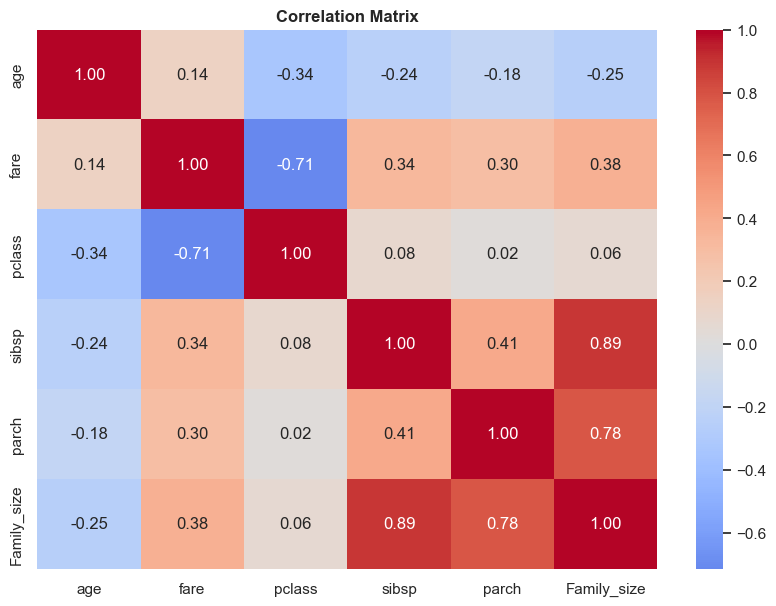

In [52]:
numeric_features = ['survived', 'age', 'fare', 'pclass', 'sibsp', 'parch', 'Family_size']
corr = df_filtered[numeric_features].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix', fontweight='bold')
plt.show()

#### Correlation Analysis

#### Business Insight
- Fare and passenger class show a strong relationship.

No extremely strong correlations exist among most variables, indicating that multiple factors contributed to survival.

In [53]:
# Generate the main survival rates used for the final interpretation.
df_filtered['survived'] = df_filtered['survived'].astype('Int64')

print('Overall survival rate:', round(df_filtered['survived'].mean() * 100, 2), '%')

print('\nSurvival rate by sex:')
print((df_filtered.groupby('who')['survived'].mean() * 100).round(2))

print('\nSurvival rate by passenger class:')
print((df_filtered.groupby('pclass')['survived'].mean() * 100).round(2))

print('\nSurvival rate by embarkation town:')
print((df_filtered.groupby('embark_town')['survived'].mean() * 100).round(2))

Overall survival rate: 38.25 %

Survival rate by sex:
who
child    59.04
man      16.39
woman    75.46
Name: survived, dtype: Float64

Survival rate by passenger class:
pclass
0    62.62
1    47.28
2    24.24
Name: survived, dtype: Float64

Survival rate by embarkation town:
embark_town
Cherbourg      55.36
Queenstown     38.96
Southampton     33.7
Name: survived, dtype: Float64


In [54]:
df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,fare_scaled,age_scaled,fare_log,age_power,Family_size,Age_category
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.818876,0.375000,2.110213,-0.560017,2,Adult
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0,2.043417,0.682692,4.280593,0.752492,2,Adult
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0,-0.785784,0.451923,2.188856,-0.224824,1,Adult
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0,1.428918,0.625000,3.990834,0.511554,2,Adult
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.779656,0.625000,2.202765,0.511554,1,Adult


In [55]:
df_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,fare_scaled,age_scaled,fare_log,age_power,Family_size,Age_category
0,0,2,male,22.0,1,0,7.2500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.818876,0.375000,2.110213,-0.560017,2,Adult
1,1,0,female,38.0,1,0,65.6344,woman,Cherbourg,1.0,0.0,1.0,0.0,0.0,2.043417,0.682692,4.280593,0.752492,2,Adult
2,1,2,female,26.0,0,0,7.9250,woman,Southampton,1.0,0.0,0.0,0.0,1.0,-0.785784,0.451923,2.188856,-0.224824,1,Adult
3,1,0,female,35.0,1,0,53.1000,woman,Southampton,1.0,0.0,0.0,0.0,1.0,1.428918,0.625000,3.990834,0.511554,2,Adult
4,0,2,male,35.0,0,0,8.0500,man,Southampton,0.0,1.0,0.0,0.0,1.0,-0.779656,0.625000,2.202765,0.511554,1,Adult


In [56]:
df_filtered['sex'] = df_filtered['sex'].map({
    'male': 0,
    'female': 1
})

x = df_filtered[['sex','age','fare','Family_size']].fillna(0)
y = df_filtered['survived'].fillna(0)

selector = SelectKBest(score_func= f_classif , k =2)
x_new = selector.fit_transform(x,y)
selected_features = x.columns[selector.get_support()]

print(f"Selected Features: {selected_features}")

Selected Features: Index(['sex', 'fare'], dtype='object')


# Final Conclusions

After performing exploratory data analysis, several important factors influencing survival were identified.

Survival in the Titanic dataset was not random. It was mainly influenced by gender and passenger class, where females and first-class passengers had significantly higher survival rates. Age played a smaller role compared to these dominant factors.

## Key Findings

1. Female passengers had significantly higher survival rates than males.

2. First-class passengers were more likely to survive than second- and third-class passengers.

3. Younger passengers generally experienced better survival outcomes.

4. Higher ticket fares were associated with higher survival rates.

5. Family size influenced survival, with small families showing better outcomes than very large families or solo travelers.

6. Passenger class, fare, gender, age, and family-related features all appear to be important predictors of survival.